In [76]:
from fileinput import filename
import xarray as xr
from pathlib import Path
import numpy as np
import os
import matplotlib as mpl
mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}"
    })

plt.rcParams.update({'font.size': 20, 'axes.titlesize': 24, 'axes.labelsize': 20, 'legend.fontsize': 14, 'xtick.labelsize': 20, 'ytick.labelsize': 20})


In [73]:
# Update: Use 'lon' and 'lat' as coordinate names and global range
regions_plot = {
    "Africa": {"color": "#c2896c", "lon": [15, 35], "lat": [-20, 5]},
    "Tropical Indian": {"color": "#8fa9b5", "lon": [55, 95], "lat": [-20, 0]},
    "Maritime Continent": {"color": "#bd5172", "lon": [95, 150], "lat": [-10, 10]},
    "North Pacific": {"color": "#797bd0", "lon": [140, 200], "lat": [15, 30]},
    "Tropical Pacific": {"color": "#77587e", "lon": [160, 200], "lat": [-20, 0]},
    "South America": {"color": "#c86c62", "lon": [285, 320], "lat": [-15, 0]},
}

In [74]:
imerg_data_utc = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_2023_utc.nc').pr


In [75]:
ccic_data_utc = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018_2023_utc.nc').tiwp

In [41]:
seasons_months = [
    [12, 1, 2],  # DJF
    [3, 4, 5],   # MAM
    [6, 7, 8],   # JJA
    [9, 10, 11]  # SON']
]

seasons_imerg_data=[]
seasons_ccic_data=[]
for months in seasons_months:
    seasons_imerg_data.append(imerg_data_utc.sel(month=months).mean(dim='month'))
    seasons_ccic_data.append(ccic_data_utc.sel(month=months).mean(dim='month'))

seasons_imerg_data_avg = xr.concat(seasons_imerg_data, dim='season')
seasons_ccic_data_avg = xr.concat(seasons_ccic_data, dim='season')

In [42]:
seasons_imerg_data_sa = seasons_imerg_data_avg.sel(lat=slice(-15,0), lon=slice(285, 320))
seasons_ccic_data_sa = seasons_ccic_data_avg.sel(lat=slice(-15,0), lon=slice(285, 320))

In [ ]:
utc_hour = imerg_data_utc['hour_of_day']
lst = (utc_hour + imerg_data_utc['lon'] / 360 * 24) % 24
seasons_imerg_data_sa_lst = seasons_imerg_data_sa.assign_coords(LST=lst)
seasons_ccic_data_sa_lst = seasons_ccic_data_sa.assign_coords(LST=lst)
seasons_imerg_data_sa_lst_stack = (
    seasons_imerg_data_sa_lst
    .stack(points=('hour_of_day', 'lon'))
    .groupby_bins('LST', np.arange(0, 25, 1))
    .mean('points')
)

seasons_ccic_data_sa_lst_stack = (
    seasons_ccic_data_sa_lst
    .stack(points=('hour_of_day', 'lon'))
    .groupby_bins('LST', np.arange(0, 25, 1))
    .mean('points')
)

def weighted_average(da):
    weights = np.cos(np.deg2rad(da['lat']))
    # no weights
    weights.name = "weights"
    # Weighted mean over lat/lon/month
    avg = da.weighted(weights).mean(dim=["lat"])
    return avg
seasons_imerg_data_sa_lst_avg = weighted_average(seasons_imerg_data_sa_lst_stack)
seasons_ccic_data_sa_lst_avg = weighted_average(seasons_ccic_data_sa_lst_stack)

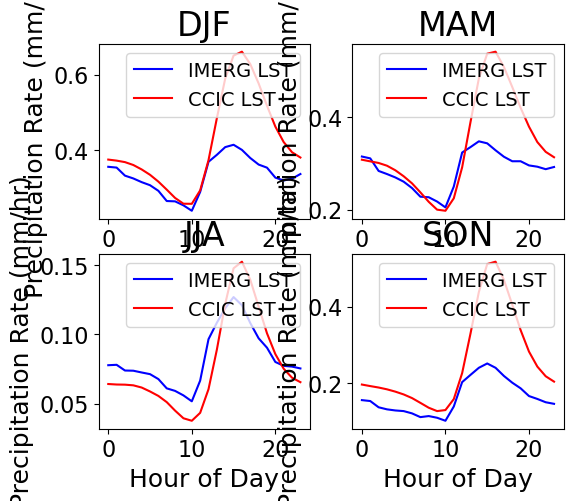

In [56]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2, figsize=(6,5))
ax = axs.flatten()
for season_idx in range(4):
    ax[season_idx].plot(range(0,24), seasons_imerg_data_sa_lst_avg.sel(season=season_idx), label='IMERG LST', color='blue')
    ax[season_idx].plot(range(0,24), seasons_ccic_data_sa_lst_avg.sel(season=season_idx), label='CCIC LST', color='red')
    ax[season_idx].set_title(['DJF', 'MAM', 'JJA', 'SON'][season_idx])
    ax[season_idx].set_xlabel('Hour of Day')
    ax[season_idx].set_ylabel('Precipitation Rate (mm/hr)')
    ax[season_idx].legend()
                                                             

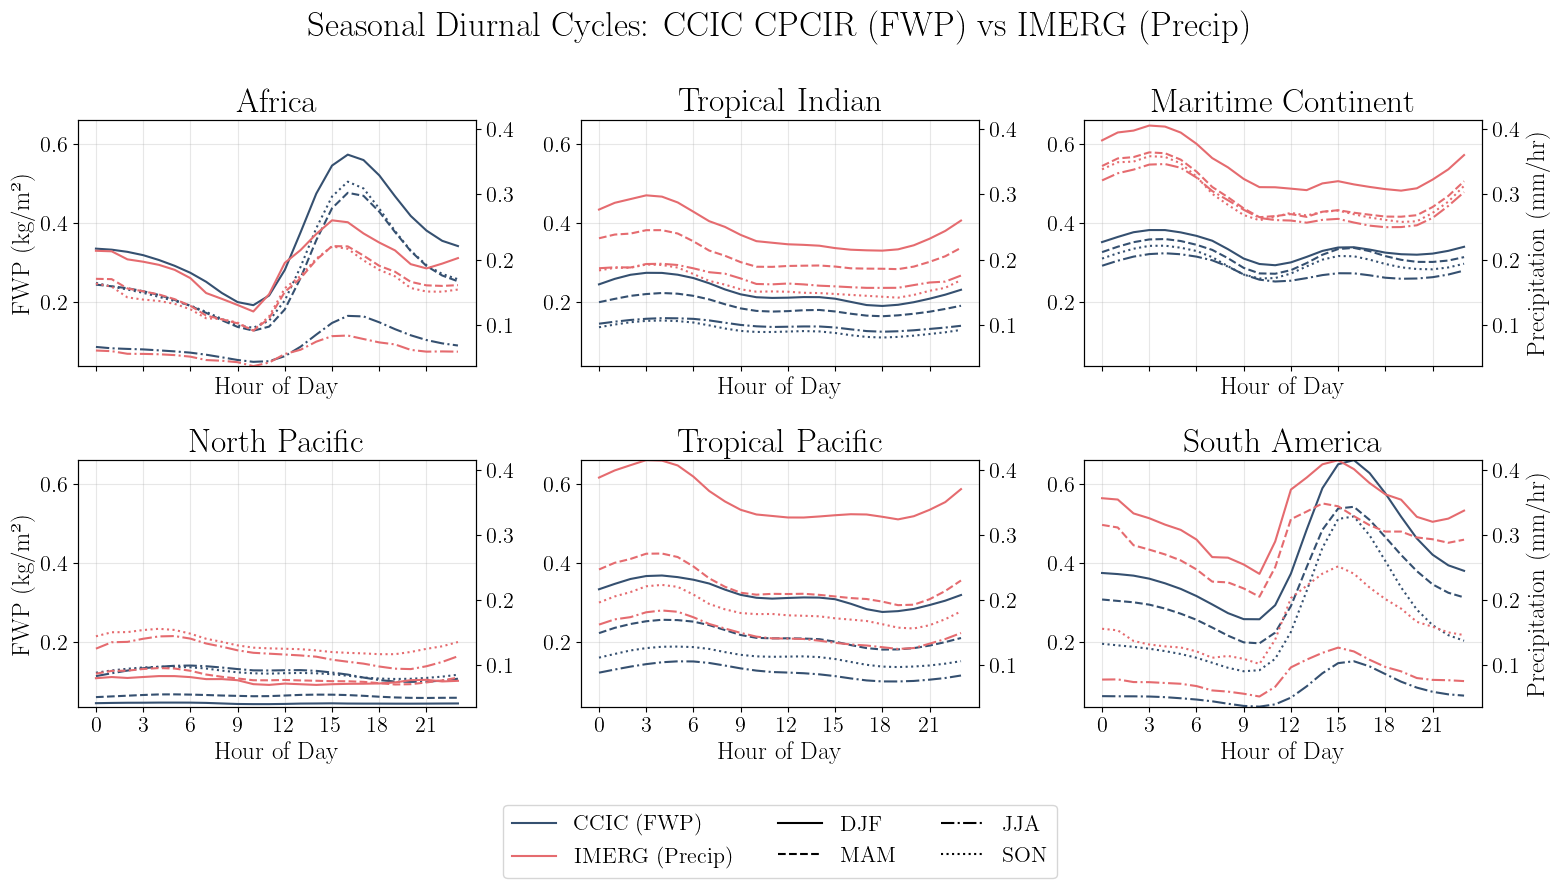

Saved figure to pdf/Regional_diurnal_CCIC_IMERG.pdf


In [78]:
# Option to show relative values (divide by mean)
show_relative = False  # Set to True for relative values
same_y_axis = True  # Set to True to have same y-axis for all subplots
# Define seasons as month lists
seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11]
}

# Weighted mean over region and months
def seasonal_diurnal(ds, region, months):
    ds = ds.assign_coords(lon=(((ds.lon + 360) % 360)))

    seasons_ds = ds.sel(month=months).mean(dim='month')

    seasons_ds_region = seasons_ds.sel(lat=slice(region['lat'][0], region['lat'][1]),
                                       lon=slice(region['lon'][0], region['lon'][1]))

    # Conversion to LST
    utc_hour = ds['hour_of_day']
    lst = (utc_hour + ds['lon'] / 360 * 24) % 24
    seasons_ds_region_lst = seasons_ds_region.assign_coords(LST=lst)

    seasons_ds_region_lst_stack = (
        seasons_ds_region_lst
        .stack(points=('hour_of_day', 'lon'))
        .groupby_bins('LST', np.arange(0, 25, 1))
        .mean('points')
)

    # Weighted average
    weights = np.cos(np.deg2rad(seasons_ds_region_lst['lat']))
    # no weights
    weights.name = "weights"
    # Weighted mean over lat/lon/month
    seasons_ds_region_lst_avg = seasons_ds_region_lst_stack.weighted(weights).mean(dim=["lat"])

    return seasons_ds_region_lst_avg
       

# Variable names (update if needed)
ccic_var = 'tiwp'  # or the correct variable name in ccic
imerg_var = 'pr'  # or the correct variable name in IMERG

# Colorblind-friendly palette (matplotlib tab10)
season_linestyles = [
    '-',
    '--',
    '-.',
    ':'
]

ccic_color = '#355070'  
imerg_color = '#e56b6fff' 
season_names = ['DJF', 'MAM', 'JJA', 'SON']

plt.rcParams.update({'font.size': 20, 'axes.titlesize': 24, 'axes.labelsize': 18, 'legend.fontsize': 14, 'xtick.labelsize': 16, 'ytick.labelsize': 16})
ratio = [2,3]
figsize = (16, 8)

fig, axes = plt.subplots(ratio[0], ratio[1], figsize=figsize, sharex=True, sharey=False)
axes = axes.flatten()

# Have the same y axis for all subplots
ccic_min, ccic_max = np.inf, -np.inf
imerg_min, imerg_max = np.inf, -np.inf
for region in regions_plot.values():
    for months in seasons.values():
        ccic_cycle = seasonal_diurnal(ccic_data_utc, region, months)
        imerg_cycle = seasonal_diurnal(imerg_data_utc, region, months)
        if show_relative:
            ccic_cycle = (ccic_cycle / ccic_cycle.mean() -1)*100
            imerg_cycle = (imerg_cycle / imerg_cycle.mean() -1)*100
        ccic_min = min(ccic_min, float(np.nanmin(ccic_cycle)))
        ccic_max = max(ccic_max, float(np.nanmax(ccic_cycle)))
        imerg_min = min(imerg_min, float(np.nanmin(imerg_cycle)))
        imerg_max = max(imerg_max, float(np.nanmax(imerg_cycle)))
                                                   

for i, (region_name, region) in enumerate(regions_plot.items()):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    for j, (season, months) in enumerate(seasons.items()):
        # CCIC (TIWP) on left y-axis
        ccic_cycle = seasonal_diurnal(ccic_data_utc, region, months)
        if show_relative:
            ccic_cycle = (ccic_cycle / ccic_cycle.mean() -1)*100
        ax1.plot(ccic_data_utc['hour_of_day'], ccic_cycle, color=ccic_color, linestyle=season_linestyles[j])
        # IMERG (Precipitation) on right y-axis
        imerg_cycle = seasonal_diurnal(imerg_data_utc, region, months)
        if show_relative:
            imerg_cycle = (imerg_cycle / imerg_cycle.mean() -1)*100
        ax2.plot(imerg_data_utc['hour_of_day'], imerg_cycle, color=imerg_color, linestyle=season_linestyles[j])
    ax1.set_title(region_name)
    ax1.set_xlabel('Hour of Day')
    ax1.set_xticks([0,3,6,9,12,15,18,21])
    # Only set y-labels on leftmost and rightmost subplots
    if i % ratio[1] == 0:
        ax1.set_ylabel('FWP (kg/m²)' if not show_relative else 'Relative FWP', color='black')
    else:
        ax1.set_ylabel('')
    if (i + 1) % ratio[1] == 0:
        ax2.set_ylabel('Precipitation (mm/hr)' if not show_relative else 'Relative Precipitation', color='black')
    else:
        ax2.set_ylabel('')
    ax1.grid(True, alpha=0.3)
    if same_y_axis:
        ax1.set_ylim(ccic_min, ccic_max)
        ax2.set_ylim(imerg_min, imerg_max)

# Custom legend handles
import matplotlib.lines as mlines
dataset_handles = [
    mlines.Line2D([], [], color=ccic_color, label='CCIC (FWP)'),
    mlines.Line2D([], [], color=imerg_color, label='IMERG (Precip)')
]
season_handles = [
    mlines.Line2D([], [], color='black', linestyle=season_linestyles[i], label=season_names[i])
    for i in range(4)
 ]

fig.legend(dataset_handles + season_handles, [h.get_label() for h in dataset_handles + season_handles],
           loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3, fontsize=16, frameon=True)

plt.suptitle('Seasonal Diurnal Cycles: CCIC CPCIR (FWP) vs IMERG (Precip)' + (' (Relative)' if show_relative else ''), fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 1])
name = 'pdf/Regional_diurnal_CCIC_IMERG' + ('_relative' if show_relative else '') + ('_dify' if not same_y_axis else '') + '.pdf'
plt.savefig(name, bbox_inches='tight')
plt.show()
print(f'Saved figure to {name}')